In [88]:
import torch
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import cmocean as cmo
import numpy as np

In [89]:
data = torch.load('forward_solvers/mesh-data/circles_bfgs_200_res_128_noise_0.0.pt')
imgs_true = data['imgs_true']
imgs_pred = data['imgs_pred']
sigma_true = data['sigma_true']
sigma_pred = data['sigma_pred']

Text(0.5, 1.0, 'Predicted Image')

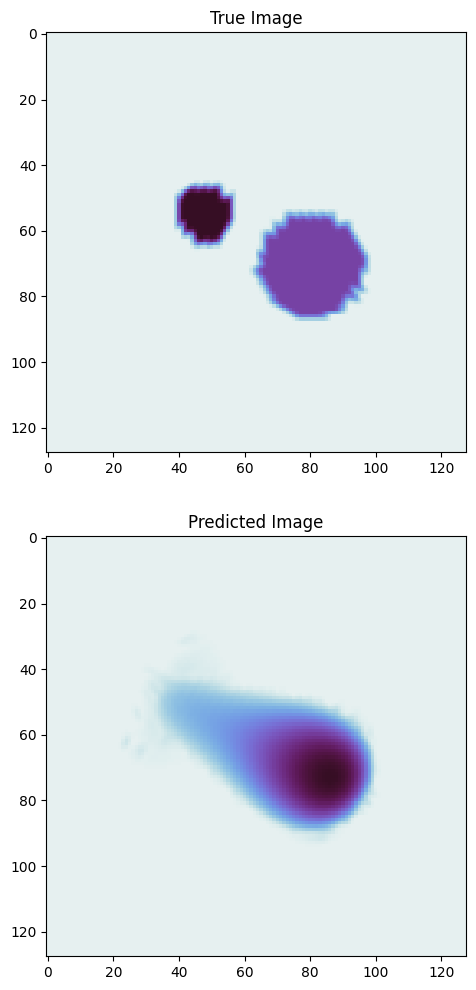

In [90]:
# plot images
sigma_true = sigma_true.cpu().numpy()
sigma_pred = sigma_pred.cpu().numpy()

# plot
fig, axs = plt.subplots(2, 1, figsize=(12, 12))
axs[0].imshow(imgs_true[0], cmap=cmo.cm.dense)
axs[0].set_title('True Image')
axs[1].imshow(imgs_pred[0], cmap=cmo.cm.dense)
axs[1].set_title('Predicted Image')



In [91]:
data = np.load('forward_solvers_numba/mesh-data/circles_bfgs_200_res_128_noise_0.0.npz')
imgs_true = data['imgs_true']
imgs_pred = data['imgs_pred']
sigma_true = data['sigma_true']
sigma_pred = data['sigma_pred']

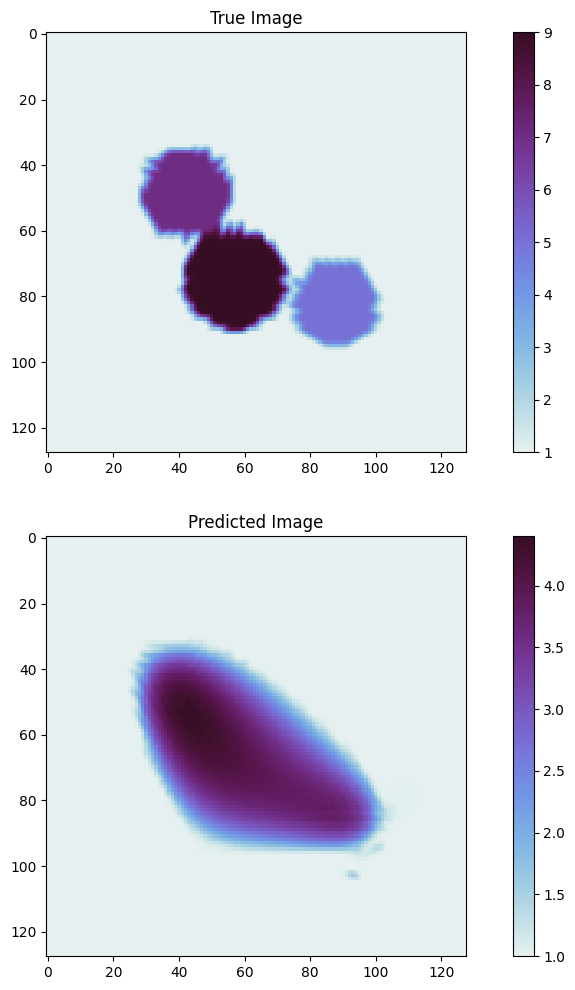

In [92]:
# plot images
sigma_true = sigma_true
sigma_pred = sigma_pred

# plot
fig, axs = plt.subplots(2, 1, figsize=(12, 12))
axs[0].imshow(imgs_true[0], cmap=cmo.cm.dense)
axs[0].set_title('True Image')
# add colorbar
fig.colorbar(axs[0].imshow(imgs_true[0], cmap=cmo.cm.dense), ax=axs[0])

axs[1].imshow(imgs_pred[0], cmap=cmo.cm.dense)
axs[1].set_title('Predicted Image')
# add colorbar
fig.colorbar(axs[1].imshow(imgs_pred[0], cmap=cmo.cm.dense), ax=axs[1])

plt.show()


In [93]:
data = torch.load('forward_solvers/mesh-data/sl_bfgs_400_res_128_noise_0.0.pt')
imgs_true = data['imgs_true']
imgs_pred = data['imgs_pred']
sigma_true = data['sigma_true']
sigma_pred = data['sigma_pred']

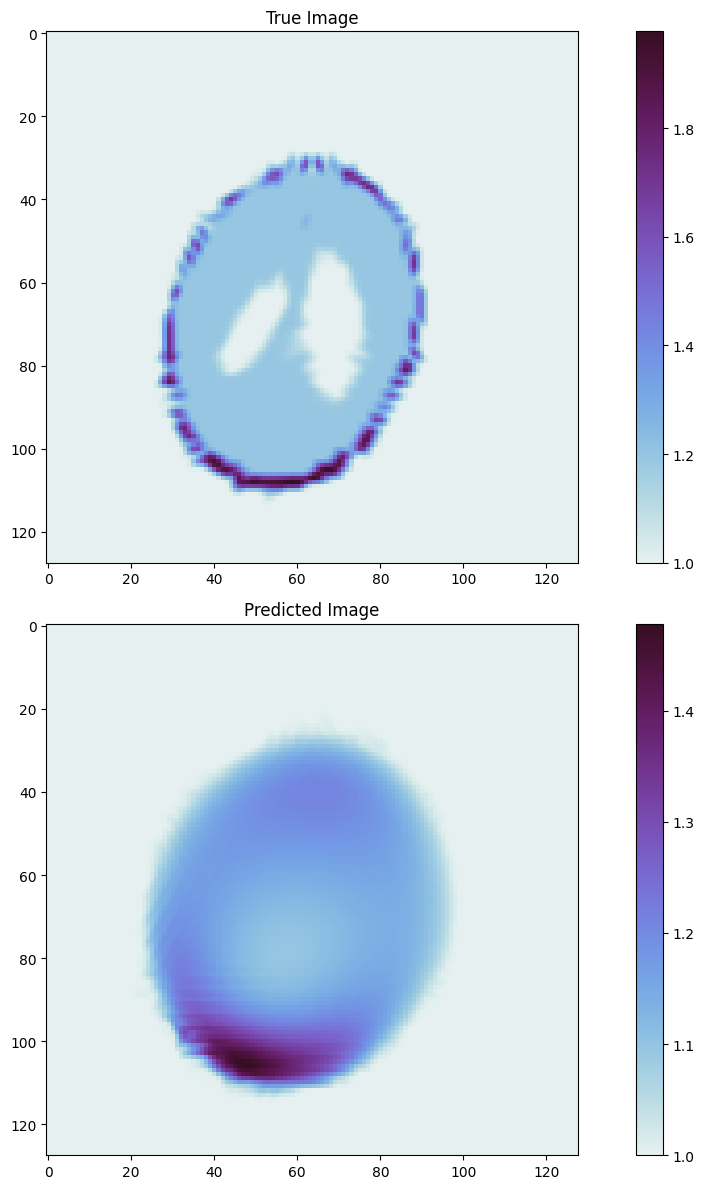

In [94]:
# plot images
sigma_true = sigma_true.cpu().numpy()
sigma_pred = sigma_pred.cpu().numpy()

# plot
fig, axs = plt.subplots(2, 1, figsize=(12, 12))
axs[0].imshow(imgs_true[0], cmap=cmo.cm.dense)
axs[0].set_title('True Image')
# add colorbar
fig.colorbar(axs[0].imshow(imgs_true[0], cmap=cmo.cm.dense), ax=axs[0])
axs[1].imshow(imgs_pred[0], cmap=cmo.cm.dense)
axs[1].set_title('Predicted Image')
# add colorbar
fig.colorbar(axs[1].imshow(imgs_pred[0], cmap=cmo.cm.dense), ax=axs[1])
plt.tight_layout()
plt.show()


In [95]:
data = np.load('forward_solvers_numba/mesh-data/sl_bfgs_400_res_128_noise_0.0.npz')
imgs_true = data['imgs_true']
imgs_pred = data['imgs_pred']
sigma_true = data['sigma_true']
sigma_pred = data['sigma_pred']

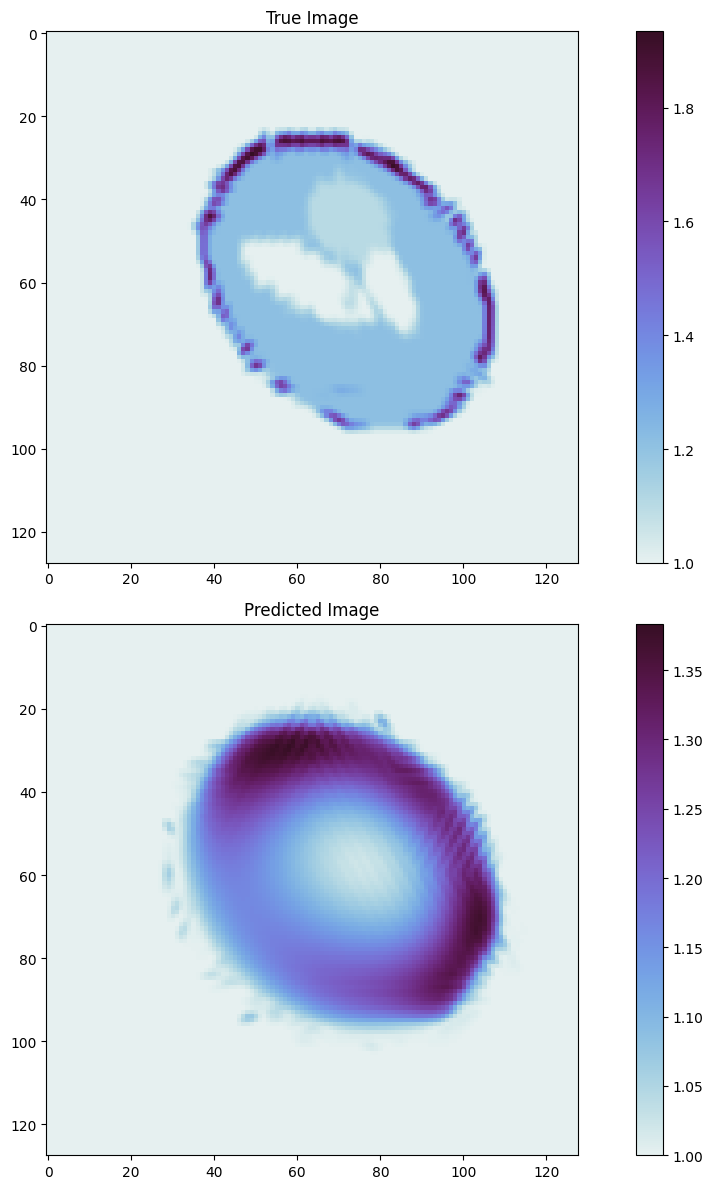

In [96]:
# plot images
sigma_true = sigma_true
sigma_pred = sigma_pred

# plot
fig, axs = plt.subplots(2, 1, figsize=(12, 12))
axs[0].imshow(imgs_true[0], cmap=cmo.cm.dense)
axs[0].set_title('True Image')
# colorbar
fig.colorbar(axs[0].imshow(imgs_true[0], cmap=cmo.cm.dense), ax=axs[0])
axs[1].imshow(imgs_pred[0], cmap=cmo.cm.dense)
axs[1].set_title('Predicted Image')
# colorbar
fig.colorbar(axs[1].imshow(imgs_pred[0], cmap=cmo.cm.dense), ax=axs[1])
plt.tight_layout()
plt.show()


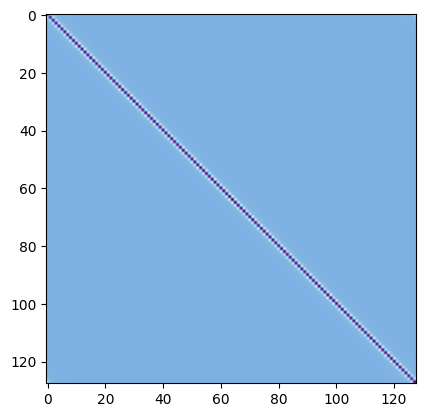

In [97]:
#geometry
import time
from forward_solvers.fem import Mesh, V_h, dtn_map
from forward_solvers.utils import interpolate_pts, generate_GCOORD, assemble_EL_connectivity
fem_solve_config = {
    'method': 'lstsq', # why using lstsq? because spsolve errors out if matrix is singular
    'data_root': 'forward_solvers/mesh-data',
    'mesh_file': 'mesh_128_h05.mat',
    'img_size': 128,
    'original_size': 128,
    'pad_size': 0,
    'num_iters': 150,
    'noise': 0.0,
    'nnodel': 4, #number of nodes per element
    'lx': 2,
    'ly': 2
}
dataset = torch.load('data/shepp-logan-dataset-128.pt')
# dataset = torch.load('data/circles-dataset-128.pt')
gt = dataset['test'][0].squeeze() + 1

data_root = 'forward_solvers/mesh-data'
mesh_file = 'mesh_128_h05.mat'
img_size = 128
original_size = 128
pad_size = 0
num_iters = 150
noise = 0.0

mat_fname  = os.path.join(data_root, mesh_file)
mat_contents = sio.loadmat(mat_fname)

p = torch.tensor(mat_contents['p'], dtype=torch.float64)
t = torch.tensor(mat_contents['t']-1, dtype=torch.long) 
vol_idx = torch.tensor(mat_contents['vol_idx'].reshape((-1,))-1, dtype=torch.long)
bdy_idx = torch.tensor(mat_contents['bdy_idx'].reshape((-1,))-1, dtype=torch.long)

mesh = Mesh(p, t, bdy_idx, vol_idx)
v_h = V_h(mesh)

num_samples = 1
nx          = img_size + 1
ny          = img_size + 1
lx          = 2
ly          = 2
nnodel      = 4  #number of nodes per element

# model parameters
nex         = nx-1
ney         = ny-1
nnod        = nx*ny #number of nodes
nel         = nex*ney #number of finite elements

img_size_down = original_size + 2 * pad_size
x = torch.linspace(-1, 1, img_size_down, dtype=torch.float64)
y = torch.linspace(-1, 1, img_size_down, dtype=torch.float64)
xx, yy = torch.meshgrid(x, y, indexing='ij')
img_points = torch.stack([xx.ravel(), yy.ravel()]).T

# Generate a mesh for downsampling the original image. 
GCOORD_down = img_points.reshape((img_size_down, img_size_down, 2))
GCOORD_down = torch.flip(GCOORD_down, dims=[0])
GCOORD_down = GCOORD_down.reshape((-1, 2))

#generate square mesh and element connectivity
GCOORD = torch.tensor(generate_GCOORD(lx, ly, nx, ny), dtype=torch.float64)
EL2NOD = torch.tensor(assemble_EL_connectivity(nnod, nnodel, nex, nx), dtype=torch.long)



centroids = torch.mean(p[t], dim=1)  

sigma_true = torch.zeros((num_samples, len(centroids)), dtype=torch.float64)
sigma_pred = torch.zeros((num_samples, len(centroids)), dtype=torch.float64)
imgs_true = torch.zeros((num_samples, img_size, img_size), dtype=torch.float64)
imgs_pred = torch.zeros((num_samples, img_size, img_size), dtype=torch.float64)

save_name = f"sl_bfgs_{str(num_iters)}_res_{str(img_size)}_noise_{str(noise)}"
save_path = os.path.join(data_root, save_name)

for i in range(num_samples):
    sigma_vec_true = torch.from_numpy(interpolate_pts(GCOORD_down, gt.flatten(), centroids))
    dtn_data, sol = dtn_map(v_h, sigma_vec_true)
    t_i = time.time()
    
    sq_img_true = 1. + torch.zeros((nx-1) * (ny-1), dtype=torch.float64)
    sq_img_pred = 1. + torch.zeros((nx-1) * (ny-1), dtype=torch.float64)

    interp_vals_true = torch.tensor(interpolate_pts(centroids, sigma_vec_true, GCOORD), dtype=torch.float64, device=centroids.device)
    # interp_vals_pred = torch.tensor(interpolate_pts(centroids, sigma_vec_pred, GCOORD), dtype=torch.float64, device=centroids.device)
    for iel in range(0,nel):
        ECOORD_true = torch.take(interp_vals_true, EL2NOD[iel, :])
        # ECOORD_pred = torch.take(interp_vals_pred, EL2NOD[iel, :])
        
        #based on ECOORD pts, average them out to find pixel value 
        sq_img_true[iel] = torch.mean(ECOORD_true)
        # sq_img_pred[iel] = torch.mean(ECOORD_pred)
        
    t_f = time.time()

    sq_img_true = torch.flip(sq_img_true.reshape((nx-1, ny-1)), dims=[0])
    # sq_img_pred = torch.flip(sq_img_pred.reshape((nx-1, ny-1)), dims=[0])
    
    sigma_true[i, ...] = sigma_vec_true
    # sigma_pred[i, ...] = sigma_vec_pred
    imgs_true[i, ...] = sq_img_true
    # imgs_pred[i, ...] = sq_img_pred
    plt.imshow(dtn_data.reshape((nx-1, ny-1)), cmap=cmo.cm.dense)